# 03 - Ablations: which part is doing the work?

A method that only reports its final number is not testable. Two studies:

**Component ablation** - disable one mechanism at a time, so each drop is
attributable to that mechanism and not to the bundle.

**Labelled-fraction sweep** - re-train at 5/10/20/50% labels with the gradient
step count held fixed. Any semi-supervised method looks good at 50% labels,
where the supervised branch dominates; the question is the 5-10% regime. If the
gain does not shrink as labels are added, the method is probably acting as a
regulariser rather than exploiting the unlabelled pool.

Two design details make the sweep a controlled experiment rather than a set of
unrelated draws:

- `optim.steps_per_epoch` is **fixed**, so training length does not vary with
  label count.
- Labelled subsets are **nested** - raising the fraction strictly adds images.

In [1]:
# Run from the repository root, or from notebooks/ - both work.
import sys, os
from pathlib import Path

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
    os.chdir(root)
sys.path.insert(0, str(root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, (os.cpu_count() or 2)))
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
print("repo root :", root)
print("torch     :", torch.__version__, "| cuda:", torch.cuda.is_available())

repo root : F:\projects\new ai projects\evidential-semi-supervised-lesion-segmentation
torch     : 2.13.0+cpu | cuda: False


In [2]:
QUICK = True   # the sweep re-trains many times; start small

SCALE = ([
    "data.image_size=48", "data.train_size=200", "data.val_size=32",
    "data.test_size=64", "data.batch_size=6", "data.mu=1",
    "model.width=12", "model.depth=3",
    "optim.epochs=6", "optim.steps_per_epoch=8",
    "loss.kl_anneal_epochs=3", "semi.rampup_epochs=2", "eval.bootstrap=500",
    "run.out_dir=results/scratch",
] if QUICK else [
    "data.image_size=64", "data.train_size=600", "data.val_size=80",
    "data.test_size=150", "data.batch_size=8", "data.mu=2",
    "model.width=16", "model.depth=3",
    "optim.epochs=24", "optim.steps_per_epoch=24",
    "loss.kl_anneal_epochs=10", "semi.rampup_epochs=8",
    "run.out_dir=results/scratch",
])

## Nested labelled subsets, verified

The property the sweep depends on, checked before spending compute on it.

In [3]:
import dataclasses
from evissl.config import DataConfig
from evissl.data import build_dataset

base = DataConfig(name="synthetic", image_size=32, train_size=400,
                  val_size=8, test_size=8)
previous, rows = set(), []
for fraction in (0.05, 0.10, 0.20, 0.50, 1.0):
    bundle = build_dataset(dataclasses.replace(base, labeled_fraction=fraction), seed=1337)
    current = set(bundle.labeled_idx.tolist())
    rows.append({
        "fraction": fraction,
        "n_labeled": len(current),
        "is superset of previous": previous.issubset(current),
        "added": len(current - previous),
    })
    previous = current
display(pd.DataFrame(rows))

,fraction,n_labeled,is superset of previous,added
0,0.05,20,True,20
1,0.10,40,True,20
2,0.20,80,True,40
3,0.50,200,True,120
4,1.00,400,True,200


## Component ablation

In [4]:
from evissl.pipelines import run_component_ablation

ablation = run_component_ablation(
    "configs/evidential.yaml", overrides=SCALE, out_dir="results/scratch")
display(ablation.round(4))

18:36:38 | INFO    | ablation_full | separable_unet | 0.144M params | 0.014 GMACs | {'dataset': 'synthetic', 'image_size': 48, 'n_train': 200, 'n_labeled': 20, 'n_unlabeled': 180, 'n_val': 32, 'n_test': 64, 'lesion_pixel_fraction': 0.1659}


18:36:43 | INFO    | run=ablation_full method=evidential head=evidential epochs=6 steps/epoch=8 (2.7 passes over the labelled set) device=cpu


18:36:54 | INFO    | epoch 0 | loss=1.4243 | val_dice=0.0001  <- best | 10.3s


18:37:00 | INFO    | epoch 1 | loss=1.5853 | val_dice=0.0000 | 5.4s


18:37:05 | INFO    | epoch 2 | loss=2.0642 | val_dice=0.5352  <- best | 4.5s


...

18:41:29 | INFO    | epoch 4 | loss=1.7983 | val_dice=0.5984  <- best | 6.1s


18:41:37 | INFO    | epoch 5 | loss=1.7785 | val_dice=0.6036  <- best | 7.4s


18:41:37 | INFO    | done: best val_dice=0.6036 at epoch 5


18:41:40 | INFO    | wrote results\scratch\tables\ablation_components.csv


,variant,changed,dice,iou,hd95,boundary_f1,ece,ause,delta_dice,delta_iou,delta_boundary_f1
0,full,(none),0.5877,0.4461,11.1389,0.3230,0.2516,0.1625,0.0000,0.0000,0.0000
1,no_dissonance_temper,semi.temperature=1.0,0.5907,0.4492,11.0022,0.3285,0.2583,0.1718,0.0030,0.0031,0.0055
2,no_vacuity_gate,semi.use_vacuity_gate=false,0.5879,0.4464,11.1335,0.3243,0.2519,0.1629,0.0002,0.0003,0.0013
3,no_kl,loss.kl_weight=0.0,0.5872,0.4458,11.2040,0.3226,0.2505,0.1615,-0.0005,-0.0003,-0.0004
4,no_axial,model.axial_attention=false,0.5564,0.4128,12.1956,0.2506,0.2162,0.1616,-0.0313,-0.0333,-0.0724
5,gate_without_evidential_loss,loss.supervised=ce_dice,0.6051,0.4646,9.9249,0.3604,0.1609,0.1928,0.0174,0.0185,0.0374


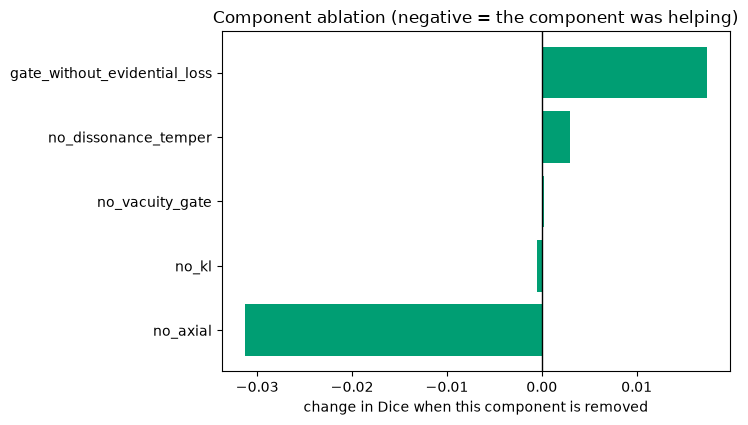

In [5]:
if not ablation.empty and "delta_dice" in ablation:
    view = ablation[ablation["variant"] != "full"].sort_values("delta_dice")
    fig, ax = plt.subplots(figsize=(7.5, 0.55 * len(view) + 1.6))
    ax.barh(view["variant"], view["delta_dice"], color="#009E73")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("change in Dice when this component is removed")
    ax.set_title("Component ablation (negative = the component was helping)")
    ax.grid(axis="y", visible=False)
    plt.tight_layout(); plt.show()

What each row tests:

| variant | removes | question it answers |
|---|---|---|
| `no_dissonance_temper` | per-pixel temperature | is softening ambiguous boundaries worth anything? |
| `no_vacuity_gate` | belief-mass weighting | is the weighting doing the work, or just the loss? |
| `no_kl` | evidential KL regulariser | does vacuity stay informative without it? |
| `no_axial` | bottleneck attention | how much is architecture rather than ideology? |
| `gate_without_evidential_loss` | the evidential *objective*, keeping the gate | does the rule need the training objective, or just the arithmetic? |

`no_kl` is the one to watch. Without a penalty on misleading evidence the
network can lower its loss by inflating evidence everywhere; vacuity then
collapses towards zero for every pixel and the gate degenerates into Mean
Teacher.

## Labelled-fraction sweep

In [6]:
from evissl.pipelines import run_labeled_fraction_sweep
from evissl.report import write_sweep_figure

sweep = run_labeled_fraction_sweep(
    ["configs/supervised_baseline.yaml", "configs/fixmatch.yaml",
     "configs/evidential.yaml"],
    fractions=(0.05, 0.10, 0.20, 0.50),
    overrides=SCALE,
    out_dir="results/scratch",
)
display(sweep["table"].round(4))
print(write_sweep_figure(sweep, "results/scratch"))

18:41:43 | INFO    | supervised_baseline_lf005 | separable_unet | 0.144M params | 0.014 GMACs | {'dataset': 'synthetic', 'image_size': 48, 'n_train': 200, 'n_labeled': 10, 'n_unlabeled': 190, 'n_val': 32, 'n_test': 64, 'lesion_pixel_fraction': 0.1659}


18:41:43 | INFO    | run=supervised_baseline_lf005 method=none head=ce_dice epochs=6 steps/epoch=8 (4.0 passes over the labelled set) device=cpu


18:41:48 | INFO    | epoch 0 | loss=1.3861 | val_dice=0.0006  <- best | 4.1s


18:41:53 | INFO    | epoch 1 | loss=1.3693 | val_dice=0.0000 | 5.0s


18:41:59 | INFO    | epoch 2 | loss=1.2644 | val_dice=0.5605  <- best | 4.9s


...

19:01:13 | INFO    | done: best val_dice=0.6447 at epoch 3


19:01:19 | INFO    | wrote results\scratch\tables\labeled_fraction_sweep.csv


,method,labeled_fraction,n_labeled,dice,ci_lower,ci_upper,iou,hd95,boundary_f1,ece,ause
0,supervised,0.05,10,0.5986,0.5464,0.6467,0.4531,12.9447,0.3415,0.1718,0.1915
1,fixmatch,0.05,10,0.6071,0.5517,0.6595,0.4683,10.1065,0.3734,0.1595,0.2135
2,evidential,0.05,10,0.6013,0.5502,0.6551,0.4606,10.6451,0.3543,0.2653,0.1881
3,supervised,0.10,20,0.6063,0.5541,0.6589,0.4676,10.3687,0.3765,0.1551,0.1958
4,fixmatch,0.10,20,0.5962,0.5429,0.6488,0.4553,10.4396,0.3371,0.1459,0.2045
5,evidential,0.10,20,0.5877,0.5385,0.6411,0.4461,11.1389,0.3230,0.2516,0.1625
6,supervised,0.20,40,0.6142,0.5626,0.6652,0.4740,9.7896,0.4099,0.1721,0.1906
7,fixmatch,0.20,40,0.6296,0.5816,0.6777,0.4893,9.4624,0.4174,0.1850,0.1671
8,evidential,0.20,40,0.6207,0.5721,0.6679,0.4813,9.9066,0.4032,0.2893,0.1545
9,supervised,0.50,100,0.6229,0.5742,0.6712,0.4815,9.8889,0.4042,0.1874,0.1671


19:01:19 | INFO    | wrote results\scratch\figures\labeled_fraction_sweep.png


results\scratch\figures\labeled_fraction_sweep.png


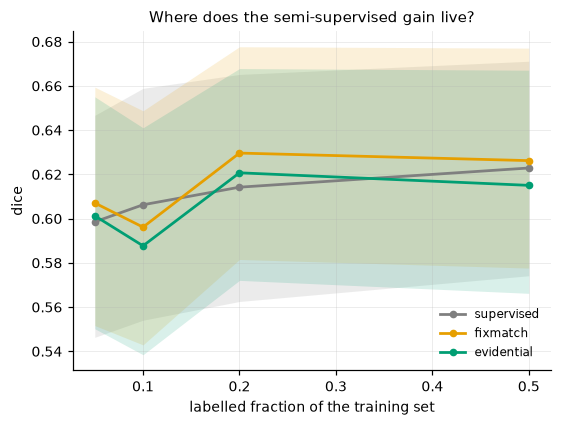


Dice gain over the supervised lower bound:


method,evidential,fixmatch
labeled_fraction,,
0.05,0.0027,0.0085
0.10,-0.0186,-0.0101
0.20,0.0065,0.0154
0.50,-0.0078,0.0033


In [7]:
from evissl.viz import plot_sweep

fig = plot_sweep(sweep["sweep"], metric="dice",
                 xlabel="labelled fraction of the training set",
                 title="Where does the semi-supervised gain live?")
plt.show()

# The gain over the supervised lower bound, per label budget.
frame = sweep["table"]
if {"method", "labeled_fraction", "dice"} <= set(frame.columns):
    wide = frame.pivot_table(index="labeled_fraction", columns="method", values="dice")
    if "supervised" in wide:
        gain = wide.drop(columns=["supervised"]).sub(wide["supervised"], axis=0)
        print("\nDice gain over the supervised lower bound:")
        display(gain.round(4))

Read the gain table, not the absolute numbers. A healthy semi-supervised method
shows its largest gain at the smallest label budget and converges towards the
supervised bound as labels accumulate - because there is progressively less for
the unlabelled pool to add.